# Forecasting Next-Day PM2.5 in Dublin Using Mobile Air Quality, Weather, and Traffic Data

**Research question:**

Can next-day air pollution in Dublin be predicted from recent pollution levels, weather and traffic conditions, and what does this imply for DCC’s monitoring and intervention strategy?

**Target variable:** 

Particulate matter pollution, specifically PM2.5, particles with a size (diameter) of less than 2.5 micrometers 

**Rationale for PM2.5**

PM2.5 is used as the dependent variable because particulate matter is identified by Our World in Data as the main contributor to poor health from air pollution, with higher death rates than ozone, and PM2.5 is especially harmful because its very small particles can penetrate deep into the respiratory system.

**Data sources**

- Google Air View
- weather dataset *(TBD)*
- traffic dataset *(TBD)*

## 1. Setup

- imports
- random seed
- file paths

In [2]:
#Import Libraries

#Basic
%matplotlib inline
import numpy as np
import pandas as pd
import math


#Plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
#Testing Ellen that it works

## 2. Data loading

- load main pollution dataset, weather dataset, and traffic dataset
- quick shape and column check

In [3]:
data_airview = pd.read_csv('../data/raw/AirView_DublinCity_Measurements_ugm3.csv')

In [8]:
print(data_airview.shape)

(5030143, 15)


In [9]:
print(data_airview.columns)

Index(['gps_timestamp', 'latitude', 'longitude', 'NO_ugm3', 'NO2_ugm3',
       'O3_ugm3', 'CO_mgm3', 'CO2_mgm3', 'PMch1_perL', 'PMch2_perL',
       'PMch3_perL', 'PMch4_perL', 'PMch5_perL', 'PMch6_perL', 'PM25_ugm3'],
      dtype='object')


## 3. Data understanding
- variable overview
- time coverage
- granularity
- missingness

### 3.1 Air View data understanding

In [4]:
#Stripped DF with just PM2.5 ugm^3 and car metrics
df = data_airview[['gps_timestamp', 'latitude' , 'longitude' , 'PM25_ugm3']]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5030143 entries, 0 to 5030142
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   gps_timestamp  str    
 1   latitude       float64
 2   longitude      float64
 3   PM25_ugm3      float64
dtypes: float64(3), str(1)
memory usage: 153.5 MB


In [5]:
df = df.copy()
df.loc[:, "timestamp"] = pd.to_datetime(
    df["gps_timestamp"],
    format="%Y-%m-%d %H:%M:%S %Z"
)

In [ ]:
#Check for missingness
df.isna().sum()

In [ ]:
#Determine the percentage of rows with missing PM2.5 recordings
missing_rows = df[df["PM25_ugm3"].isna()] #highlight row mask for plotting

percentage_missing = len(missing_rows) / len(df) * 100
print(round(percentage_missing,2), "% of all rows have missing PM2.5 values")

In [6]:
#For easy plotting add date /time column
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

In [ ]:
# Basic time stats
print("Date range:", df['date'].min(), "to", df['date'].max())

total_days = (df['date'].max() - df['date'].min()).days + 1 #add 1 for  both first/last day
observed_days = df["date"].nunique() #unique dates
percentage_days = (observed_days / total_days) * 100

print(f"The car took readings on {observed_days} days out of the total {total_days} days in range"
      f"({percentage_days:.2f}% of days)")

In [ ]:
# Car times of day
print("Time range:", df['time'].min(), "to", df['time'].max())

In [ ]:
#Days of week recordings
df['weekday'] = df['timestamp'].dt.day_name()
weekday_counts = df['weekday'].value_counts().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])
print(weekday_counts)

Evidently the car only captured measurements on weekdays, with Tuesday having the largest number of recordings. On average, Monday and Friday have the lowest number of recordings of all the weekdays.

In [ ]:
#Visualise recordings weekly and monthly
df['date'] = pd.to_datetime(df['date'])
weekly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'W')).size()
monthly_counts = df.groupby(pd.Grouper(key = 'date', freq = 'ME')).size()

#Both in subplots
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 1, figsize=(12, 8))  # 2x1

# Weekly plot
weekly_counts.index = weekly_counts.index.strftime('%d-%m-%y')
weekly_counts.plot(ax=axes[0], kind='bar', color = 'lightblue')
axes[0].set_title('Car Recordings per Week')
axes[0].set_xlabel('Week Beginning')
axes[0].set_ylabel('Number of Recordings')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=10)

# Monthly plot
monthly_counts.index = monthly_counts.index.strftime('%b-%y')
monthly_counts.plot(ax=axes[1], kind='bar', color = 'lightgreen')
axes[1].set_title('Car Recordings per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Recordings')
axes[1].tick_params(axis='x', rotation=30, labelsize=10)
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Distribution of missing values

weekly_missing = df.groupby(pd.Grouper(key = 'timestamp', freq = 'W'))['PM25_ugm3'].apply(lambda x: x.isna().sum())
weekly_missing = weekly_missing.reset_index()
weekly_missing.columns = ['week_start', 'missing_count']
weekly_missing['week_label'] = weekly_missing['week_start'].dt.strftime('%d-%b-%y')

sns.set_theme(style='white')

# Plot
plt.figure(figsize=(12,5))
sns.barplot(x='week_label', y='missing_count', data=weekly_missing, color='navy', edgecolor='black')
plt.xlabel('Week Starting')
plt.ylabel('Number of Missing Measurements')
plt.title('Weekly Count of Missing PM2.5 Measurements (Machine Malfunctions)')

# Rotate x-axis
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

PM2.5 Recordings

In [ ]:
# Number of unique measurements
num_unique = df['PM25_ugm3'].nunique(dropna=True)
print(f"Number of unique PM25_ugm3 measurements: {num_unique}")

#Range of Measurements
df['PM25_ugm3'].describe()
#from this can see that there are no negative recordings but some very large recordings way above mean and top quartile

News articles remark expectionally high measures of PM2.5 of 400 in Rathmines in 2020, the highest measure since the 80s. There does not appear to be any news article reporting of any further anomaly events, suggesting that it is reasonable to assume any records beyond this level are machine errors. (https://www.breakingnews.ie/ireland/dublins-air-pollution-hits-highest-levels-since-the-1980s-1044551.html)

In [ ]:
#Outliers
print(((df['PM25_ugm3'] > 400).sum()), "of the", ((df['PM25_ugm3'] > 0).sum()), 
      "readings are above 400ugm3, i.e. ", round(((df['PM25_ugm3'] > 400).mean() * 100),6), "%")

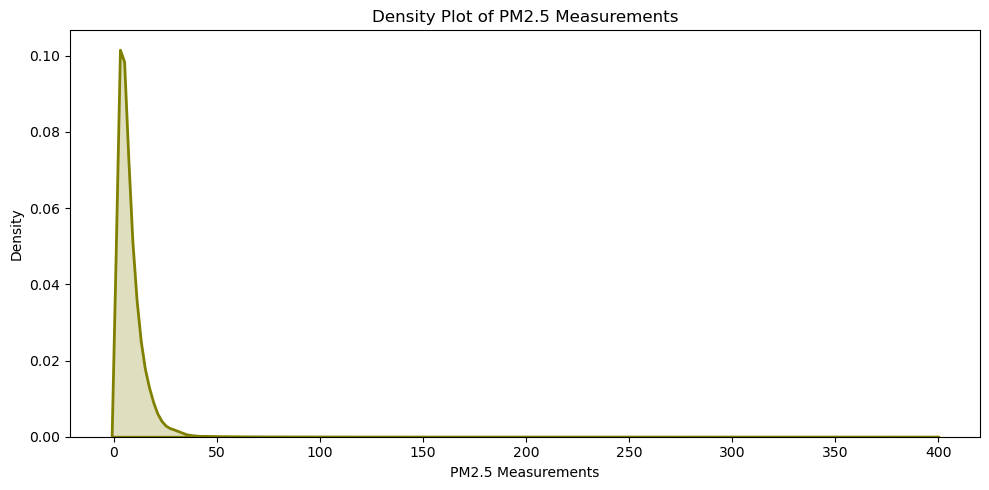

In [7]:
#Removing them
df_clean = df[df['PM25_ugm3'] <= 400].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

In [ ]:
#Smaller density 
df_clean = df[df['PM25_ugm3'] <= 50].dropna()

plt.figure(figsize=(10,5))
sns.kdeplot(df_clean['PM25_ugm3'], fill=True, color='olive', linewidth=2)

plt.xlabel('PM2.5 Measurements')
plt.ylabel('Density')
plt.title('Density Plot of PM2.5 Measurements')

plt.tight_layout()
plt.show()

In [ ]:
# Average measurement over time 
daily_avg = df_clean.groupby('date')['PM25_ugm3'].mean()
daily_avg.plot(figsize=(14,5))
plt.xlabel("Date")
plt.ylabel("Average Measurement")
plt.title("Daily Average Measurement")
plt.show()

In [ ]:
# Heatmap hour
pivot = df_clean.pivot_table(
    values='PM25_ugm3',
    index='date',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,10))
sns.heatmap(pivot, cmap="viridis")

plt.xlabel("Hour")
plt.ylabel("Date")
plt.title("Measurements by Date and Hour")
plt.show()

Location

In [ ]:
#Approximate km^2 area car drove around
lat_min = df['latitude'].min()
lat_max = df['latitude'].max()
lon_min = df['longitude'].min()
lon_max = df['longitude'].max()

# Very rough conversion is 1 degree lat/long approxes to 111km
# Approximate conversion
lat_km = (lat_max - lat_min) * 111
mean_lat = df['latitude'].mean()
lon_km = (lon_max - lon_min) * 111 * math.cos(math.radians(mean_lat)) #times the cos(lat)

# Approximate area
area_km2 = lat_km * lon_km

print(f"Approximate area covered by car: {area_km2:.2f} km²")

In [ ]:
#lat/long by pm2.5

plt.figure(figsize=(8,6))
scatter = sns.scatterplot(
    x='longitude', 
    y='latitude', 
    hue='PM25_ugm3',       # color by recording
    palette='viridis',  # colormap palette
    data=df_clean,
    s=20               # size of points
)

plt.title("Latitude vs Longitude colored by Metric")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.2 Weather data understanding

In [2]:
# Import dataset and skip the metadata at the top
weather_df = pd.read_csv('../data/external/airport_weather.csv', skiprows = 25)

In [3]:
# Change dates to date time objects
weather_df['date'] = weather_df['date'].astype('datetime64[ms]')

# Include only 2021 dates in the dataframe and reset index
weather_2021 = weather_df[weather_df['date'].dt.year == 2021].reset_index(drop = True)
weather_2021.index += 1 # Switch index to start from 1

In [4]:
# Remove unnecessary columns
weather_2021 = weather_2021.drop(columns = ['ind', 'ind.1', 'igmin', 'ind.2', 'gmin', 'ind.3', 'ind.4', 'ddhm', 'ind.5', 'dos', 'smd_wd', 'smd_md', 'smd_pd', 'cbl', 'soil'])

### 3.3 Traffic data understanding

## 4. Data merging & cleaning
- merge datasets into one table
- drop all columns we don't need
- parse timestamps
- standardise column names if needed
- remove exact duplicates
- drop invalid or missing timestamps
- drop invalid or missing coordinates where needed
- drop missing PM2.5 where needed
- basic validation of key fields

## 5. Feasibility checks

### 5.1 Location revisit frequency

important because next-day prediction at a location is only credible if the same places are observed repeatedly over time.

### 5.2 Day-to-day timestamp density
important because forecasting needs a sufficiently continuous daily series rather than sporadic snapshots.

### 5.3 Daily target feasibility

This section tests whether PM2.5 can be aggregated into a meaningful daily target. The main question is whether daily summaries are based on reasonably comparable daily coverage rather than highly uneven sampling.

### 5.4 Target framing decision

The final decision is whether the target should really be interpreted as **“next-day city-level daytime PM2.5 observed by Air View”** rather than general **“next-day Dublin PM2.5”**. This distinction matters because Air View is a mobile sensing platform with its own coverage pattern.